# Chapter 10: The Superforecaster
Update odds with evidence, validate probability aggregation and test a Fermi
estimate's assumptions. All events and quantities are seeded synthetic examples.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.special import expit,logit
rng=begin(10)

## Multiply odds, not probabilities, by a likelihood ratio

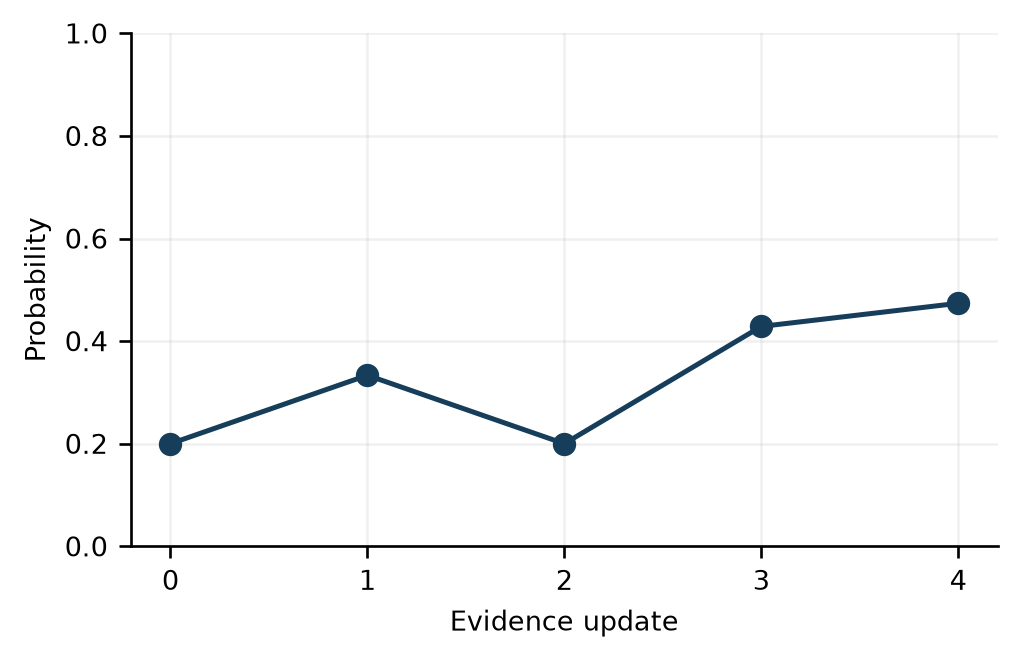

In [2]:
prior=.2; odds=prior/(1-prior); values=[prior]
for likelihood_ratio in [2.,.5,3.,1.2]:
    odds*=likelihood_ratio; values.append(odds/(1+odds))
assert np.isclose(values[1],1/3)
plt.figure(); plt.plot(values,'o-'); plt.ylim(0,1); plt.xticks(range(len(values))); plt.xlabel('Evidence update'); plt.ylabel('Probability')
save(10,1,'Evidence updates the odds','Illustrative likelihood ratios update a 20% prior. Evidence dependence must be accounted for before multiplying ratios.','## The Methodology')

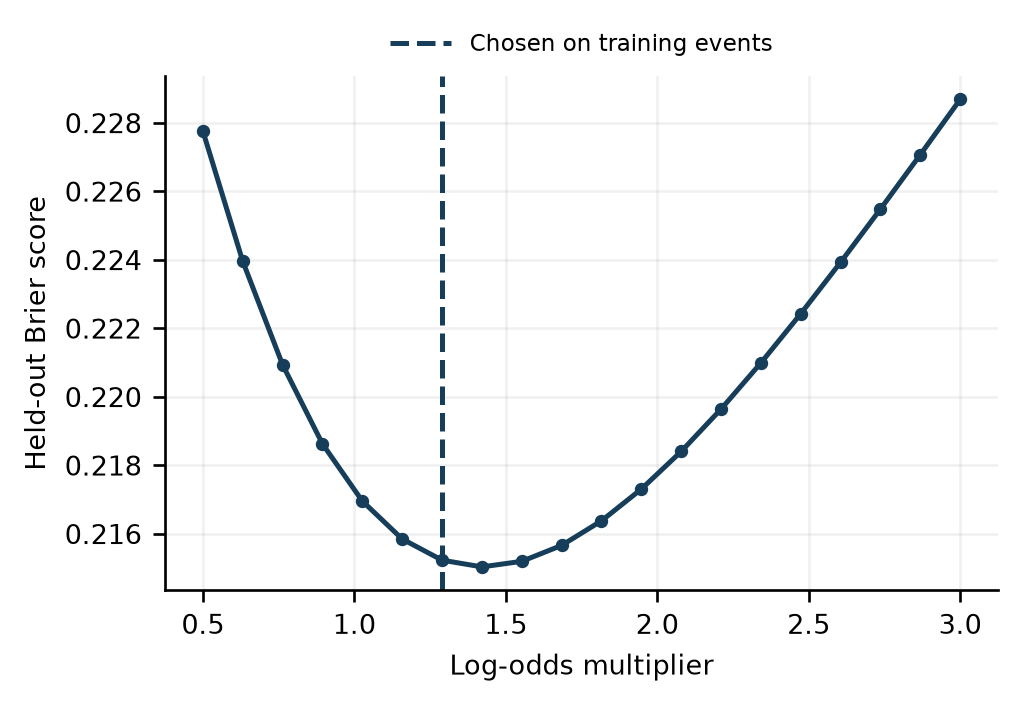

In [3]:
truth=expit(rng.normal(size=4000)); outcomes=rng.binomial(1,truth)
expert=expit(.65*logit(truth)[:,None]+rng.normal(0,.8,(4000,8))); average=expert.mean(axis=1)
strengths=np.linspace(.5,3,20); errors=[]
for strength in strengths: errors.append(brier(expit(strength*logit(average[2000:])),outcomes[2000:]))
train_scores=[brier(expit(s*logit(average[:2000])),outcomes[:2000]) for s in strengths]; chosen=strengths[np.argmin(train_scores)]
plt.figure(); plt.plot(strengths,errors,'o-',ms=3); plt.axvline(chosen,ls='--',label='Chosen on training events'); plt.xlabel('Log-odds multiplier'); plt.ylabel('Held-out Brier score'); plt.legend(fontsize=7)
save(10,2,'Extremization needs validation','Synthetic independent event groups. The multiplier is selected on the first 2,000 events and evaluated on a separate 2,000.','## The Methodology')

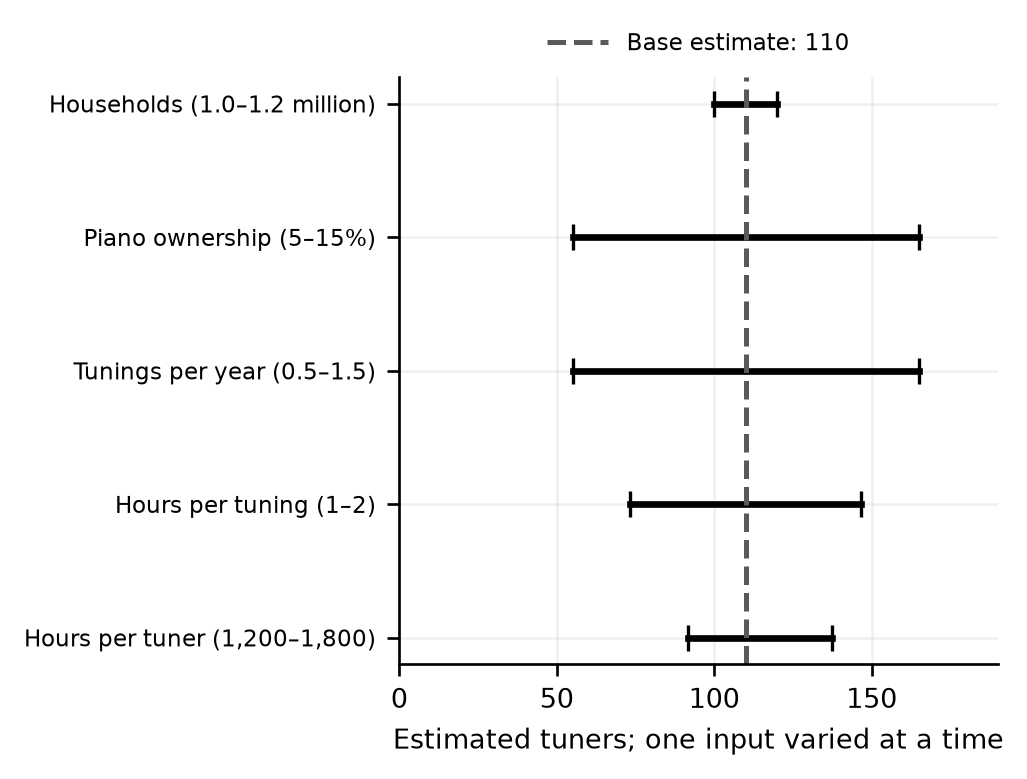

Base Fermi tuner estimate 110.0 training-selected multiplier 1.2894736842105263


In [4]:
# Piano-tuner arithmetic matches the adjacent book example. The ranges below
# are deliberately illustrative sensitivity assumptions, not measured Chicago
# inputs, confidence intervals, or independent probability distributions.
tuner_inputs=np.array([1_100_000., .10, 1., 1.5, 1500.])
tuner_base=float(np.prod(tuner_inputs[:4])/tuner_inputs[4])
tuner_scenarios={}
for i,(label,low,high) in enumerate([
    ('Households (1.0–1.2 million)',1_000_000,1_200_000),
    ('Piano ownership (5–15%)',.05,.15),
    ('Tunings per year (0.5–1.5)',.5,1.5),
    ('Hours per tuning (1–2)',1.,2.),
    ('Hours per tuner (1,200–1,800)',1200.,1800.)]):
    estimates=[]
    for value in [low,high]:
        varied=tuner_inputs.copy(); varied[i]=value
        estimates.append(float(np.prod(varied[:4])/varied[4]))
    tuner_scenarios[label]=sorted(estimates)
fig,ax=plt.subplots(figsize=(4.3,3.3))
for row,(label,(low,high)) in enumerate(tuner_scenarios.items()):
    ax.plot([low,high],[row,row],color='black',lw=2)
    ax.plot([low,high],[row,row],'|',color='black',ms=8)
ax.axvline(tuner_base,color='.35',ls='--',label='Base estimate: 110')
ax.set_yticks(range(5),list(tuner_scenarios)); ax.tick_params(axis='y',labelsize=7)
ax.invert_yaxis(); ax.set_xlim(0,190)
ax.set_xlabel('Estimated tuners; one input varied at a time')
ax.legend()
save(10,3,'Which assumptions deserve more investigation?','Piano-tuner example: 1.1 million households × 10% ownership × one annual tuning × 1.5 hours, divided by 1,500 annual hours per tuner, gives 110. Ranges are illustrative assumptions, not measured uncertainty or confidence intervals. Each row varies only its named input; wider spans identify greater sensitivity under these selected ranges.','## The Methodology',fig)
print('Base Fermi tuner estimate',tuner_base,'training-selected multiplier',chosen)

## Limits and exercise
Add a common expert bias: do more experts fix it? Multiplication of component
means is generally not the mean of a product when inputs are dependent. Maintain
a forecast journal and compute scores only after outcomes resolve.

## A usable event journal: define, update, resolve, score
A probability question needs a deadline, timezone, resolution source and rules
for ambiguous outcomes. Record a base rate before outcomes, initial reasoning,
disconfirming evidence, and what would change your mind. Preserve every update.
Do not invent a numerical likelihood ratio for a news item; a documented judgment
update is preferable to false precision. AI personas are not independent experts.
The following saved JSON is an editable teaching artifact, NOT a tamper-proof log.
Real applications need timestamped append-only/versioned storage.

In [5]:
from forecasting_companion.practitioner import score_journal
import json, os
from datetime import datetime, timedelta, timezone
origin=datetime(2024,1,1,tzinfo=timezone.utc)
events=[]; revisions=[]
for i in range(120):
    deadline=origin+timedelta(days=30+i)
    p=float(rng.uniform(.1,.9)); event_id=f'synthetic-{i:03d}'
    events.append(dict(event_id=event_id,question='Will this synthetic binary event occur?',
        cutoff=(deadline-timedelta(days=7)).isoformat(),deadline=deadline.isoformat(),
        resolution_source='Seeded synthetic Bernoulli generator',
        resolution_rule='Generator outcome 1 is yes; missing outcome remains unresolved',
        baseline=.5,outcome=int(rng.binomial(1,p)) if i<100 else None,
        resolved_at=deadline.isoformat() if i<100 else None))
    for days,estimate,reason in [(14,.5,'Initial base rate'),(8,p,'Synthetic signal; assumed reliability')]:
        revisions.append(dict(event_id=event_id,timestamp=(deadline-timedelta(days=days)).isoformat(),
            probability=estimate,reason=reason,evidence_source='Synthetic example',
            counterargument='Signal may be miscalibrated',update_trigger='New independently informative evidence'))
# Add an unmistakable hindsight entry to prove it is excluded from scoring.
revisions.append(dict(event_id=events[0]['event_id'],timestamp=(origin+timedelta(days=31)).isoformat(),
    probability=float(events[0]['outcome']),reason='Late entry: excluded',evidence_source='Outcome already known'))
scored=score_journal(events,revisions,as_of='2026-09-18T00:00:00+00:00')
assert len(scored)==100 and scored[0]['timestamp'] != revisions[-1]['timestamp']
assert all(r['event_id'] not in {e['event_id'] for e in events if e['outcome'] is None} for r in scored)
print({'resolved_scored':len(scored),'unresolved_excluded':20,'late_revisions_excluded':1,
       'mean_Brier':float(np.mean([r['brier'] for r in scored])),
       'baseline_Brier':float(np.mean([r['baseline_brier'] for r in scored]))})
folder=Path(os.environ.get('FORECAST_OUTPUT',project/'companion'))/'results'
_ = (folder/'ch10-event-journal.json').write_text(json.dumps(dict(events=events,revisions=revisions,scored=scored),indent=2)+'\n')

{'resolved_scored': 100, 'unresolved_excluded': 20, 'late_revisions_excluded': 1, 'mean_Brier': 0.20415200561479346, 'baseline_Brier': 0.25}


## Calibration is a repeated-event diagnostic, not a verdict on one forecast
Score one latest eligible forecast per event at the predeclared seven-day lead.
Do not weight frequently revised events more heavily. Show counts in bins: this
small example cannot certify calibration. Compare skill on later events before
adopting an aggregation or extremization rule. The baseline is recorded in advance.

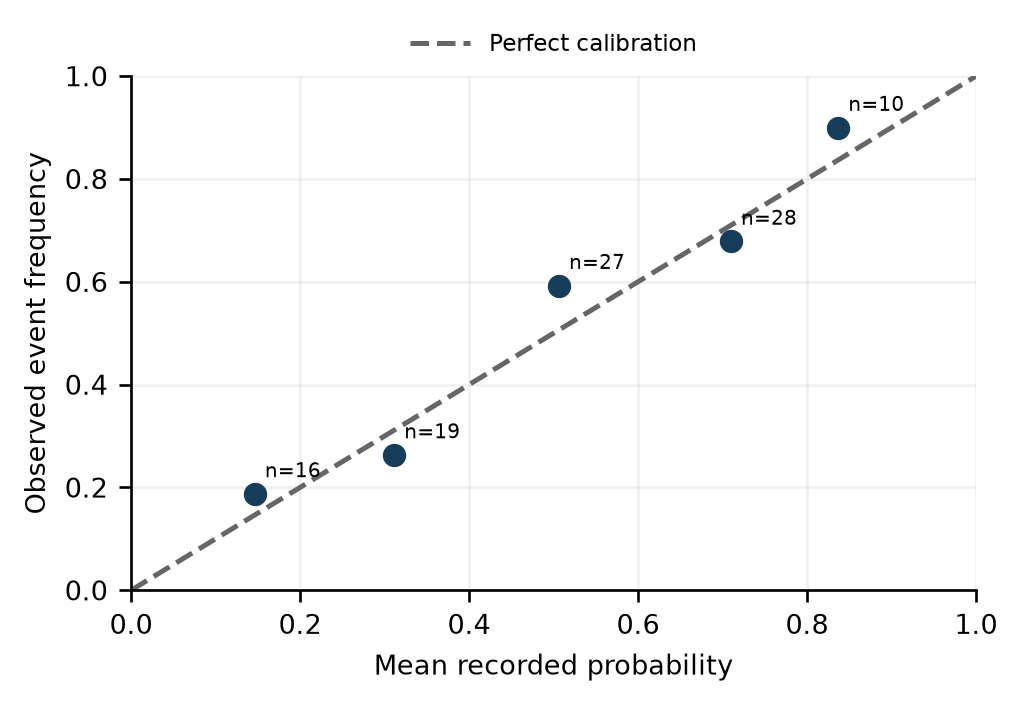

In [6]:
prob=np.array([r['probability'] for r in scored]); actual=np.array([r['outcome'] for r in scored])
plt.figure(); plt.plot([0,1],[0,1],'--',color='.4',label='Perfect calibration')
for lower,upper in zip(np.linspace(0,1,6)[:-1],np.linspace(0,1,6)[1:]):
    mask=(prob>=lower)&(prob<upper if upper<1 else prob<=upper)
    if mask.any():
        x,y=prob[mask].mean(),actual[mask].mean()
        plt.plot(x,y,'o',color='#163d59'); plt.annotate(f'n={mask.sum()}',(x,y),xytext=(3,5),textcoords='offset points',fontsize=6)
plt.xlim(0,1); plt.ylim(0,1); plt.xlabel('Mean recorded probability'); plt.ylabel('Observed event frequency'); plt.legend(fontsize=6)
save(10,4,'Keep the forecast before learning the outcome','One hundred resolved synthetic events, one pre-cutoff forecast per event; twenty unresolved events and a hindsight update are excluded. Bin counts reveal limited support; the plot does not certify real-world calibration.','## Practicing the Skill')

## Link the launch model to a probability question
Chapter 27 supplies a conditional volume forecast and sensitivity scenarios.
A question such as 'Will 24-month sales exceed 50,000 units?' additionally needs
defensible uncertainty over inputs, dependence and model error. Three scenarios
do not automatically define probabilities. Record the event in this journal,
update as trial/distribution evidence arrives, and assess it after resolution.
Prediction of success is distinct from the causal effect of increasing spend.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
Two linked tables or a JSON journal: events require event_id, question, cutoff, deadline, resolution_source, resolution_rule, baseline; outcome is 0/1 or null with resolved_at. Revisions require event_id,timestamp,probability,reason,evidence_source,counterargument,update_trigger. Timestamps include timezone; probabilities lie in [0,1]. Retain every revision.

Minimal **journal-format illustration**, unresolved and therefore not yet scoreable:

```json
{
  "events": [
    {
      "event_id": "launch-1",
      "question": "Will 24-month units exceed 50000?",
      "cutoff": "2026-09-18T12:00:00+00:00",
      "deadline": "2028-09-18T12:00:00+00:00",
      "resolution_source": "Audited sales register",
      "resolution_rule": "Strictly greater than 50000 net units",
      "baseline": 0.2,
      "outcome": null,
      "resolved_at": null
    }
  ],
  "revisions": [
    {
      "event_id": "launch-1",
      "timestamp": "2026-09-18T12:00:00+00:00",
      "probability": 0.2,
      "reason": "Comparable launches",
      "evidence_source": "Internal cohort",
      "counterargument": "Channel access differs",
      "update_trigger": "Distribution agreement signed"
    }
  ]
}
```

## Explain the mechanism

Superforecasting is a disciplined sequence of questions, evidence and revisions. Odds provide a coherent update only when the likelihood information is meaningful. A forecast journal makes future scoring possible; it cannot recover a genuinely pre-outcome forecast after the fact.

## Work through the arithmetic

Start at p=.2: odds=.2/.8=.25. A likelihood ratio of 2 gives odds .5 and probability 1/3. A subsequent conditionally independent LR=.5 returns odds .25 and probability .2. Multiplying .2 directly by 2 would incorrectly produce .4. A prediction .7 for an event that occurs has Brier (.7-1)^2=.09.

## Adapt the lesson to reader data

Replace the synthetic events/revisions construction in the journal sublesson with user records; preserve the score_journal selection rules. Keep as_of explicit and timezone-aware. Do not overwrite originals while cleaning. The odds toy accepts assumed likelihood ratios; business news does not supply those ratios automatically. Replace the piano-tuner factors only after defining numerator and denominator units.

For this chapter, settle these questions before fitting: Exactly what counts as yes, by what deadline and timezone? Which resolution source and ambiguity rule apply? What comparable-event base rate exists? Which evidence items share a source? At what lead time will forecasts be scored?

## Interpret the actual lesson outputs

The lesson’s 100 scored events, 20 unresolved exclusions and one late-update exclusion are controlled checks of eligibility, not an audited human forecasting record. The extremization curve evaluates an earlier-selected multiplier on separate events; inspecting its later minimum and selecting again would contaminate evaluation. The tuner estimate is 110 under its assumptions, and its ranges are one-at-a-time sensitivity, not probabilities.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `event_id,probability,outcome,timestamp,brier,baseline_brier`.
- `summary.json`: `brier,baseline_brier,excluded_event_ids,unselected_revision_count` plus method, interpretation, assumptions, not_done and status.

Input is JSON with events and revisions arrays. score_journal chooses the latest eligible revision for each resolved event; if none are scoreable it returns status=needs_evidence with event_id/scoring_status rows. The JSON file can retain unresolved events, but editable timestamps are not authenticated.

## Decide what the evidence supports

Check duplicated evidence, hindsight entries and multiple revisions counted as events. Evaluate later-event Brier, calibration with counts and discrimination separately. AI personas do not supply independent information. A neat calibration curve with tiny bins is not calibration evidence.

With no defensible base rate, give a range of plausible reference classes and a labeled judgment probability if a decision requires one. Without a resolution rule, keep a draft question rather than a scoreable forecast. Null outcomes remain unresolved, never zero.

The applied deliverable must make these items inspectable: `results.csv` columns: `event_id,probability,outcome,timestamp,brier,baseline_brier`; `summary.json` keys: `brier,baseline_brier,excluded_event_ids,unselected_revision_count` plus method, interpretation, assumptions, not_done and status. Return the event contract, base-rate source, initial and current probability, complete revision journal, update triggers, resolved-event score table and exclusions. Mark editable local JSON as unauthenticated; it is not tamper-proof storage.

## Three exercises with worked solutions

### Exercise 1

Prior .4, supported LR=3: calculate the posterior.

**Worked solution.** Prior odds are 2/3; posterior odds are 2, so posterior probability is 2/3, approximately .667.

### Exercise 2

An event has revisions .3 before cutoff and .99 after resolution; outcome=1. What scores?

**Worked solution.** Only .3 is eligible. Its Brier contribution is (.3-1)^2=.49. The .99 hindsight revision is preserved but excluded.

### Exercise 3

Three launch scenarios exceed the target in two cases. Is the event probability 2/3?

**Worked solution.** No. The scenarios have no probability weights or model-error distribution. Report conditional outcomes and specify what evidence is needed to estimate event odds.

## Business-reader application

Use this request with the skill:

> Use chapter 10 to define and journal whether our launch exceeds 50,000 units within 24 months. Separate business assumptions from measured evidence, give a justified initial probability or state why one is unsupported, and predeclare resolution and scoring rules.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [7]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch10.json'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch10.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = json.loads(INPUT_PATH.read_text())
workshop_table, workshop_summary = analyze_chapter(10, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch10-workshop-results.csv', index=False)
_ = (workshop_output/'ch10-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Forecast journal scoring: latest eligible revision per resolved event
Status: passed

Interpretation: 100 resolved events scored, Brier 0.2042 against baseline 0.2500; 20 events excluded as unresolved or without an eligible forecast. Unselected revisions include superseded or ineligible entries, not necessarily errors. Editable timestamps are not authenticated; retain an external append-only history.

Assumptions:
  - Revisions were recorded at the timestamps they carry
  - One forecast per event counts: the latest revision before the cutoff
Not done:
  - No reliability bins (use chapter 9 on the scored rows)
  - No authentication of the journal timestamps

Evidence:
  brier: 0.2042
  baseline_brier: 0.25
  excluded_event_ids: <20 rows>
  unselected_revision_count: 141

Table: 100 rows, columns ['event_id', 'probability', 'outcome', 'timestamp', 'brier', 'baseline_brier']

     event_id  probability  outcome                 timestamp  brier  baseline_brier
synthetic-000        

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **What is the outside view, and did I start there before looking at the specifics?**
   A bad answer looks like this: Starting from the specifics anchors on the story and forgets how often such stories end the same way.

2. **What evidence would move this probability, in which direction, by how much, and is it in the journal?**
   A bad answer looks like this: A probability with no update triggers cannot be revised honestly when news arrives.

3. **Am I extremizing because the evidence is strong or because confidence sounds better?**
   A bad answer looks like this: Extremizing without a track record of under-confidence adds error, not skill.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).